# 03 — Modeling

**Project:** Credit Risk Assessment — *Give Me Some Credit* (Kaggle)

Notebooks `01_eda` and `02_preprocessing` explored the data and produced cleaned,
imputed, **unscaled** train/test splits (the split was made *first*, so every learned
parameter — imputation medians, winsorisation caps — is leakage-free). This notebook
trains and tunes four classifiers for the binary target `SeriousDlqin2yrs`
(1 = serious delinquency within 2 years):

1. **Logistic Regression** — interpretable linear baseline, the backbone of scorecards.
2. **Decision Tree** — non-linear, rule-based baseline.
3. **Random Forest** — a bagging ensemble of decorrelated trees.
4. **XGBoost** — a regularized gradient-boosting ensemble.

For each model we present the underlying mathematics, fit a baseline, then tune its
hyperparameters with stratified cross-validation. Before that, we settle the
imbalance-handling decision that notebook 02 deferred here, by comparing strategies
under identical CV.

**Modeling protocol**
- The stratified train/test split is **inherited from notebook 02**; we never re-split.
- Hyperparameter search runs via stratified *k*-fold CV on the **training split only**.
- Optimization metric: **ROC-AUC** (equivalently Gini = 2·AUC − 1), the standard ranking
  metric for credit risk and robust to the ~6.7% positive rate.
- The test split stays frozen on disk and is consumed only in `04_evaluation`, together
  with probability calibration and SHAP interpretation.

In [1]:
import sys

!{sys.executable} -m pip install xgboost --quiet
!{sys.executable} -m pip install imbalanced-learn --quiet



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# --- Standard libraries ---
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- scikit-learn ---
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# --- Gradient boosting ---
from xgboost import XGBClassifier

# --- Imbalanced-learn (per-fold resampling, leakage-safe) ---
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

# --- Distributions for randomized search ---
from scipy.stats import randint, uniform, loguniform

# --- Persistence ---
import joblib

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [3]:
RANDOM_STATE = 42
CV_FOLDS = 5

PROCESSED = Path("data/processed")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "SeriousDlqin2yrs"

## 1. Load the preprocessed training data

We load the cleaned, imputed, **unscaled** training split saved by `02_preprocessing`.
Scaling is applied inside the model pipelines below, fitted on training folds only, so
no information leaks across the cross-validation boundary. The labels were saved with
`index=False`, i.e. as a single column, so we squeeze them back into a `Series`.

In [4]:
X_train = pd.read_csv(PROCESSED / "X_train.csv")
y_train = pd.read_csv(PROCESSED / "y_train.csv").squeeze("columns").astype(int)

print(f"Training set: {X_train.shape}")
print(f"Features: {list(X_train.columns)}")
print(f"Train positive rate: {y_train.mean():.4f}")
X_train.head()

Training set: (120000, 12)
Features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyIncome_missing', 'NumberOfDependents_missing']
Train positive rate: 0.0668


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,NumberOfDependents_missing
0,0.1150,62.0000,0.0000,1841.0000,5390.0000,5.0000,0.0000,1.0000,0.0000,2.0000,1.0000,0.0000
1,0.0087,73.0000,0.0000,0.4986,3800.0000,6.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
2,0.2145,32.0000,0.0000,0.2120,3716.0000,8.0000,0.0000,0.0000,0.0000,2.0000,0.0000,0.0000
3,1.0000,60.0000,0.0000,118.0000,5390.0000,5.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
4,0.2305,60.0000,0.0000,1.0173,3000.0000,10.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000


## 2. The train/test split is inherited from notebook 02

The 20% stratified test set was carved out in `02_preprocessing`, **before** any
parameter was learned from the data, and saved to `data/processed/X_test.csv` /
`y_test.csv`. We deliberately do **not** split again here: re-splitting would either
duplicate the cleaning logic or partition an already-cleaned set, breaking the
leakage guarantee that splitting-first was designed to provide.

The test set is intentionally **not loaded** in this notebook. All tuning happens on the
training split via cross-validation; the test set is touched exactly once, in
`04_evaluation`.

## 3. Evaluation protocol

All hyperparameter tuning uses **stratified 5-fold cross-validation on the training
set**, scored by ROC-AUC. Stratified folds preserve the class ratio in every fold,
which matters under strong imbalance. The helper below reports the mean and standard
deviation of the CV score so models compare on a common footing.

We also record the imbalance ratio (for cost-sensitive learning) and the indices of the
binary missingness flags engineered in notebook 02 — SMOTENC needs to know which columns
are categorical so it does not interpolate a 0/1 flag into a meaningless fraction.

In [5]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Class-imbalance ratio for cost-sensitive learning (train only)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (neg/pos): {scale_pos_weight:.2f}")

# Binary missingness flags from notebook 02 — categorical for SMOTENC
cat_cols = ["MonthlyIncome_missing", "NumberOfDependents_missing"]
cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]

cv_results = {}  

def cv_report(estimator, name):
    """Run stratified CV and store/print the ROC-AUC."""
    scores = cross_val_score(estimator, X_train, y_train,
                             cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results[name] = (scores.mean(), scores.std())
    print(f"{name:<28} ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}")
    return scores

scale_pos_weight (neg/pos): 13.96


## 4. Choosing an imbalance strategy

Notebook 02 produced a SMOTENC-resampled training set but deliberately left the
*decision* of how to treat imbalance to this notebook, naming two candidates:
**cost-sensitive class weighting** and **SMOTE oversampling**. We resolve it now by
comparing three strategies under the **same** stratified CV, scored by ROC-AUC, using
Logistic Regression as a fast, transparent probe:

1. **No handling** — plain logistic regression.
2. **Class weighting** — `class_weight="balanced"` reweights the loss by inverse class
   frequency, so the rare defaults are not ignored.
3. **SMOTENC oversampling** — synthetic minority samples generated **inside each CV
   fold** through an `imblearn` pipeline.

The per-fold detail is essential. Resampling the whole training set up front and then
cross-validating leaks synthetic points into the validation folds and inflates the
score — exactly the caveat notebook 02 raised. An `imblearn` pipeline calls
`fit_resample` only on each fold's training portion and leaves the validation portion
untouched. For this reason we do **not** use the pre-resampled `X_train_resampled.csv`
file here; it is only a convenience artifact for quick inspection.

In [6]:
imbalance_strategies = {
    "No handling": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "Class weighting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                                   random_state=RANDOM_STATE)),
    ]),
    "SMOTENC oversampling": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTENC(categorical_features=cat_idx, random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
}

imb_rows = []
for name, est in imbalance_strategies.items():
    s = cross_val_score(est, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    imb_rows.append((name, s.mean(), s.std()))
    print(f"{name:<22} ROC-AUC = {s.mean():.4f} ± {s.std():.4f}")

imbalance_comparison = (
    pd.DataFrame(imb_rows, columns=["strategy", "cv_roc_auc_mean", "cv_roc_auc_std"])
    .sort_values("cv_roc_auc_mean", ascending=False)
    .reset_index(drop=True)
)
imbalance_comparison

No handling            ROC-AUC = 0.8480 ± 0.0043
Class weighting        ROC-AUC = 0.8532 ± 0.0043
SMOTENC oversampling   ROC-AUC = 0.8516 ± 0.0041


,strategy,cv_roc_auc_mean,cv_roc_auc_std
0,Class weighting,0.8532,0.0043
1,SMOTENC oversampling,0.8516,0.0041
2,No handling,0.8480,0.0043


**Decision.** Class weighting matches SMOTENC on ROC-AUC while being simpler — no extra
hyperparameter, no synthetic data — and it distorts the base rate less severely, which
keeps probability **calibration** more tractable in `04_evaluation`. We therefore adopt
the cost-sensitive approach for every model below: `class_weight="balanced"` for
logistic regression, decision tree and random forest, and `scale_pos_weight` for
XGBoost.

(If your run shows SMOTENC clearly ahead on ROC-AUC, substitute the `imblearn` pipeline
above — it is the leakage-safe way to fold resampling into CV.)

## 5. Baseline model — Logistic Regression

### 5.1 The model

Logistic regression models the **probability of default** as a sigmoid of a linear
combination of the features. With weights $\mathbf{w}$ and bias $b$:

$$
z = \mathbf{w}^\top \mathbf{x} + b,
\qquad
p = P(y=1 \mid \mathbf{x}) = \sigma(z) = \frac{1}{1 + e^{-z}}.
$$

The sigmoid squashes any real $z$ into $(0, 1)$, so the output is a valid probability.

### 5.2 Why it is the natural credit-scoring model

Rearranging the sigmoid gives the **log-odds (logit)**, which is *linear* in the features:

$$
\log \frac{p}{1-p} = \mathbf{w}^\top \mathbf{x} + b.
$$

This is exactly the structure of a credit **scorecard**: each feature contributes
additively to the log-odds of default, and a coefficient $w_j$ has a direct reading —
a one-unit increase in $x_j$ multiplies the odds of default by $e^{w_j}$ (the **odds ratio**).

### 5.3 Training objective

The labels are Bernoulli, so the likelihood is
$\prod_i p_i^{y_i}(1-p_i)^{1-y_i}$. Minimizing the **negative log-likelihood** gives the
**binary cross-entropy / log-loss**:

$$
J(\mathbf{w}) = -\frac{1}{n}\sum_{i=1}^{n}
\Big[\, y_i \log p_i + (1-y_i)\log(1-p_i) \,\Big].
$$

This loss is **convex**, so there is a single global minimum. Its gradient has a clean form:

$$
\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{n}\sum_{i=1}^{n}(p_i - y_i)\,\mathbf{x}_i,
$$

i.e. each example pushes the weights in proportion to its **prediction error** $(p_i - y_i)$.
Solvers reach the optimum with gradient-based / Newton-type methods.

### 5.4 Regularization

To control overfitting and multicollinearity we add a penalty:

- **L2 (ridge):** $\frac{\lambda}{2}\lVert \mathbf{w}\rVert_2^2$ — shrinks coefficients smoothly.
- **L1 (lasso):** $\lambda \lVert \mathbf{w}\rVert_1$ — drives some coefficients to exactly zero (feature selection).

In scikit-learn the strength is parameterized by $C = 1/\lambda$, so **smaller $C$ means stronger regularization**.

### 5.5 Imbalance and scaling

Following the comparison in §4 we use `class_weight="balanced"`, which reweights the
loss inversely to class frequency. Features are standardized (mean 0, variance 1) inside
the pipeline — required for the regularization penalty to treat all coefficients fairly
and helpful for solver convergence.

In [7]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="saga",
        random_state=RANDOM_STATE,
    )),
])

cv_report(lr_pipe, "LogReg (baseline)")

LogReg (baseline)            ROC-AUC = 0.8532 ± 0.0043


array([0.85689236, 0.84641953, 0.85113058, 0.85271542, 0.85867218])

In [8]:
lr_param_grid = {
    "clf__C": [0.01, 0.1, 1.0, 10.0],
    "clf__l1_ratio": [0.0, 1.0],   # 0.0 = L2, 1.0 = L1  (replaces 'penalty')
    "clf__solver": ["saga"],        # saga supports both L1 and L2 via l1_ratio
}

lr_search = GridSearchCV(
    lr_pipe, lr_param_grid,
    scoring="roc_auc", cv=cv, n_jobs=-1, refit=True,
)
lr_search.fit(X_train, y_train)

best_lr = lr_search.best_estimator_
cv_results["LogReg (tuned)"] = (
    lr_search.best_score_,
    lr_search.cv_results_["std_test_score"][lr_search.best_index_],
)
print("Best params:", lr_search.best_params_)
print(f"Best CV ROC-AUC: {lr_search.best_score_:.4f}")

Best params: {'clf__C': 10.0, 'clf__l1_ratio': 0.0, 'clf__solver': 'saga'}
Best CV ROC-AUC: 0.8532


## 5. Baseline model — Decision Tree

### 5.1 The model

A decision tree partitions the feature space with axis-aligned splits. Starting from
the root, it repeatedly picks a **(feature, threshold)** pair that best separates
defaulters from non-defaulters, until a stopping rule is met. A leaf predicts the
class proportions of the training examples that reach it.

### 5.2 How a split is chosen — impurity

Split quality is measured by how much it **reduces node impurity**. For a node with
class proportions $p_k$, the two common measures are:

$$
\text{Gini: } \; G = 1 - \sum_k p_k^2,
\qquad
\text{Entropy: } \; H = -\sum_k p_k \log_2 p_k.
$$

Both are 0 for a pure node and maximal for a 50/50 mix. The **information gain** of a
split is the parent impurity minus the size-weighted impurity of the children:

$$
IG = I(\text{parent}) - \sum_{c \in \{L, R\}}
\frac{n_c}{n_{\text{parent}}}\, I(c).
$$

The tree greedily selects the split with the largest gain at every node.

### 5.3 Overfitting and regularization

An unconstrained tree can grow until every leaf is pure — it memorizes the training set
and generalizes poorly (high variance). We control complexity with:

- `max_depth` — caps the number of split levels,
- `min_samples_leaf` — forces leaves to hold enough examples to be statistically meaningful,
- **cost-complexity pruning** `ccp_alpha`, which minimizes
  $R_\alpha(T) = R(T) + \alpha\,|T|$, trading training error $R(T)$ against the number of
  leaves $|T|$.

As with the other models, `class_weight="balanced"` makes the impurity calculation
cost-sensitive so defaults are not swamped by the majority class. **Trees need no
feature scaling** — splits are threshold-based and invariant to monotonic rescaling.

In [9]:
dt = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
cv_report(dt, "DecisionTree (baseline)")

DecisionTree (baseline)      ROC-AUC = 0.5972 ± 0.0042


array([0.60168766, 0.6018826 , 0.59061024, 0.59627901, 0.59567967])

In [10]:
dt_param_grid = {
    "max_depth": [3, 4, 5, 6, 8, 10],
    "min_samples_leaf": [50, 100, 200, 500],
    "criterion": ["gini", "entropy"],
}

dt_search = GridSearchCV(
    dt, dt_param_grid,
    scoring="roc_auc", cv=cv, n_jobs=-1, refit=True,
)
dt_search.fit(X_train, y_train)

best_dt = dt_search.best_estimator_
cv_results["DecisionTree (tuned)"] = (dt_search.best_score_, dt_search.cv_results_[
    "std_test_score"][dt_search.best_index_])

print("Best params:", dt_search.best_params_)
print(f"Best CV ROC-AUC: {dt_search.best_score_:.4f}")

Best params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 500}
Best CV ROC-AUC: 0.8530


In [11]:
dt_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": best_dt.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
dt_importance

,feature,importance
0,RevolvingUtilizationOfUnsecuredLines,0.5622
1,NumberOfTime30-59DaysPastDueNotWorse,0.1672
2,NumberOfTimes90DaysLate,0.1417
3,NumberOfTime60-89DaysPastDueNotWorse,0.0512
4,NumberOfOpenCreditLinesAndLoans,0.0198
5,age,0.0182
6,NumberRealEstateLoansOrLines,0.0175
7,DebtRatio,0.0152
8,MonthlyIncome,0.0055
9,NumberOfDependents,0.0015


## 6. Ensemble model — Random Forest

### 6.1 From one tree to many

A single deep tree has low bias but high variance. A **random forest** averages many
trees to cut that variance, using two sources of randomness:

1. **Bagging (bootstrap aggregating):** each tree is trained on a bootstrap sample —
   $n$ examples drawn *with replacement* from the training set.
2. **Random feature subsetting:** at each split only a random subset of features
   (typically $\sqrt{p}$ for classification) is considered.

The final probability is the average of the per-tree probabilities.

### 6.2 Why averaging works — the variance argument

Suppose we average $B$ identically distributed trees, each with variance $\sigma^2$ and
pairwise correlation $\rho$. The variance of the average is:

$$
\operatorname{Var}\!\left(\frac{1}{B}\sum_{b=1}^{B} T_b\right)
= \rho\,\sigma^2 + \frac{1-\rho}{B}\,\sigma^2.
$$

As $B \to \infty$ the second term vanishes, leaving $\rho\sigma^2$. Adding more trees can
only drive variance down to that floor — so the *real* lever is **lowering the
correlation $\rho$** between trees. That is precisely what random feature subsetting
does: it forces trees to rely on different features, decorrelating them and pushing the
floor lower. This is the key idea separating a random forest from plain bagging.

### 6.3 Out-of-bag estimate

Each bootstrap sample omits, on average, a fraction
$\left(1 - \tfrac{1}{n}\right)^{n} \to e^{-1} \approx 0.368$ of the data. These
**out-of-bag (OOB)** examples were unseen by the tree, so aggregating their predictions
yields an almost-free validation estimate without a separate hold-out.

In [12]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced_subsample",
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)
print(f"OOB score (accuracy): {rf.oob_score_:.4f}")

cv_report(rf, "RandomForest (baseline)")

OOB score (accuracy): 0.9337
RandomForest (baseline)      ROC-AUC = 0.8404 ± 0.0018


array([0.84267814, 0.83816788, 0.83836288, 0.84130471, 0.84131456])

In [13]:
rf_param_dist = {
    "n_estimators": [200, 300, 400],        
    "max_depth": [6, 10, 14, None],
    "max_features": ["sqrt", "log2", 0.3],
    "min_samples_leaf": randint(1, 30),
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        class_weight="balanced_subsample",
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
    rf_param_dist,
    n_iter=15,              
    scoring="roc_auc", cv=cv, n_jobs=-1,
    random_state=RANDOM_STATE, refit=True,
)
rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
cv_results["RandomForest (tuned)"] = (
    rf_search.best_score_,
    rf_search.cv_results_["std_test_score"][rf_search.best_index_],
)
print("Best params:", rf_search.best_params_)
print(f"Best CV ROC-AUC: {rf_search.best_score_:.4f}")

Best params: {'max_depth': 14, 'max_features': 'sqrt', 'min_samples_leaf': 19, 'n_estimators': 400}
Best CV ROC-AUC: 0.8622


We use **randomized search** rather than an exhaustive grid for the ensembles: with
~120k training rows and several hyperparameters the grid is expensive, while random
search explores a wider region for the same compute budget and tends to find comparable
optima.

### 7.4 Feature importances

Tree ensembles report importances as the total impurity decrease each feature
contributes across all splits. They are a useful sanity check but are biased toward
high-cardinality features; the model-agnostic SHAP analysis is deferred to
`04_evaluation`.

In [14]:
rf_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": best_rf.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
rf_importance

,feature,importance
0,RevolvingUtilizationOfUnsecuredLines,0.3417
1,NumberOfTime30-59DaysPastDueNotWorse,0.1524
2,NumberOfTimes90DaysLate,0.1491
3,NumberOfTime60-89DaysPastDueNotWorse,0.0877
4,age,0.0682
5,DebtRatio,0.0627
6,NumberOfOpenCreditLinesAndLoans,0.0491
7,MonthlyIncome,0.0480
8,NumberRealEstateLoansOrLines,0.0251
9,NumberOfDependents,0.0117


## 8. Ensemble model — XGBoost

### 8.1 The model — additive boosting

Where a forest builds trees *independently and averages*, gradient boosting builds them
*sequentially*, each new tree correcting the errors of the current ensemble. The
prediction is an additive sum of $K$ trees:

$$
\hat{y}_i = \sum_{k=1}^{K} f_k(\mathbf{x}_i),
\qquad
\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + f_t(\mathbf{x}_i).
$$

### 8.2 The regularized objective

At step $t$ we add the tree $f_t$ that minimizes a loss plus a complexity penalty:

$$
\mathcal{L}^{(t)} = \sum_{i=1}^{n}
l\!\big(y_i,\, \hat{y}_i^{(t-1)} + f_t(\mathbf{x}_i)\big) + \Omega(f_t),
\qquad
\Omega(f) = \gamma T + \tfrac{1}{2}\lambda \lVert w \rVert^2,
$$

where $T$ is the number of leaves and $w$ the leaf weights. The penalty $\Omega$ is what
makes XGBoost *regularized* boosting rather than plain gradient boosting.

### 8.3 Second-order approximation

XGBoost expands the loss with a **second-order Taylor approximation** around the current
prediction, using the gradient $g_i$ and Hessian $h_i$:

$$
\mathcal{L}^{(t)} \approx \sum_{i=1}^{n}
\Big[\, g_i f_t(\mathbf{x}_i) + \tfrac{1}{2} h_i f_t(\mathbf{x}_i)^2 \,\Big] + \Omega(f_t),
\qquad
g_i = \partial_{\hat{y}} l, \;\; h_i = \partial^2_{\hat{y}} l.
$$

For the logistic loss this gives the same clean quantities as logistic regression:
$g_i = p_i - y_i$ and $h_i = p_i(1 - p_i)$.

### 8.4 Optimal leaf weights and the split gain

For a fixed tree structure, the optimal weight of leaf $j$ (with example set $I_j$) is

$$
w_j^{\*} = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda},
$$

and the resulting **structure score** measuring how good the tree is, is

$$
\tilde{\mathcal{L}}^{(t)} = -\frac{1}{2}\sum_{j=1}^{T}
\frac{\big(\sum_{i \in I_j} g_i\big)^2}{\sum_{i \in I_j} h_i + \lambda} + \gamma T.
$$

When deciding whether to split a leaf into left/right children, XGBoost evaluates the
**gain**:

$$
\text{Gain} = \frac{1}{2}\left[
\frac{G_L^2}{H_L + \lambda} +
\frac{G_R^2}{H_R + \lambda} -
\frac{(G_L + G_R)^2}{H_L + H_R + \lambda}
\right] - \gamma,
$$

with $G = \sum g_i$, $H = \sum h_i$ over the relevant examples. A split is kept only if
its gain is positive, so $\gamma$ acts as a minimum-gain threshold — pruning by design.

### 8.5 Shrinkage and imbalance

Each new tree is scaled by a **learning rate** $\eta$ before being added,
$\hat{y}^{(t)} = \hat{y}^{(t-1)} + \eta f_t$, which slows learning and improves
generalization (more, smaller steps). Following §4, imbalance is handled with
`scale_pos_weight = (#negatives / #positives)`, which scales the gradient of the
positive class. We use the histogram tree method (`tree_method="hist"`) for speed.

In [15]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2, stratify=y_train, random_state=RANDOM_STATE,
)

xgb_base = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    early_stopping_rounds=50,
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
xgb_base.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

best_n = xgb_base.best_iteration + 1
print(f"Early stopping selected {best_n} trees")
print(f"Validation ROC-AUC: {roc_auc_score(y_val, xgb_base.predict_proba(X_val)[:, 1]):.4f}")

Early stopping selected 140 trees
Validation ROC-AUC: 0.8638


### 8.6 Tuning strategy

Early stopping above fixed a sensible number of trees at $\eta = 0.05$. We now tune the
**structural and regularization** hyperparameters with randomized search, holding
`n_estimators` and the learning rate fixed — this avoids the well-known coupling between
$\eta$ and the number of trees (lowering one demands raising the other) and keeps the
search interpretable.

In [16]:
xgb_param_dist = {
    "max_depth": randint(3, 8),
    "min_child_weight": randint(1, 10),
    "subsample": uniform(0.6, 0.4),         # 0.6 – 1.0
    "colsample_bytree": uniform(0.6, 0.4),  # 0.6 – 1.0
    "reg_lambda": loguniform(1e-2, 10),
    "gamma": uniform(0.0, 5.0),
}

xgb_fixed = XGBClassifier(
    n_estimators=best_n,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

xgb_search = RandomizedSearchCV(
    xgb_fixed, xgb_param_dist,
    n_iter=30,
    scoring="roc_auc", cv=cv, n_jobs=-1,
    random_state=RANDOM_STATE, refit=True,
)
xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
cv_results["XGBoost (tuned)"] = (
    xgb_search.best_score_,
    xgb_search.cv_results_["std_test_score"][xgb_search.best_index_],
)
print("Best params:", xgb_search.best_params_)
print(f"Best CV ROC-AUC: {xgb_search.best_score_:.4f}")

Best params: {'colsample_bytree': np.float64(0.7077649335194086), 'gamma': np.float64(1.220627611238871), 'max_depth': 5, 'min_child_weight': 6, 'reg_lambda': np.float64(0.045320287757648736), 'subsample': np.float64(0.8232408008069365)}
Best CV ROC-AUC: 0.8641


In [17]:
xgb_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": best_xgb.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
xgb_importance

,feature,importance
0,RevolvingUtilizationOfUnsecuredLines,0.2486
1,NumberOfTimes90DaysLate,0.2390
2,NumberOfTime30-59DaysPastDueNotWorse,0.2069
3,NumberOfTime60-89DaysPastDueNotWorse,0.1250
4,NumberRealEstateLoansOrLines,0.0404
5,age,0.0335
6,NumberOfOpenCreditLinesAndLoans,0.0291
7,MonthlyIncome_missing,0.0256
8,DebtRatio,0.0169
9,MonthlyIncome,0.0156


## 9. Cross-validation summary and model persistence

The table below ranks all candidates by their cross-validated ROC-AUC on the training
set. We then serialize every tuned model so `04_evaluation` can load them and produce
the definitive comparison on the **untouched** test set (test metrics, calibration
curves, SHAP). No model selection happens here — that decision belongs to the evaluation
notebook.

In [18]:
summary = (
    pd.DataFrame(
        [(name, m, s) for name, (m, s) in cv_results.items()],
        columns=["model", "cv_roc_auc_mean", "cv_roc_auc_std"],
    )
    .sort_values("cv_roc_auc_mean", ascending=False)
    .reset_index(drop=True)
)
summary

,model,cv_roc_auc_mean,cv_roc_auc_std
0,XGBoost (tuned),0.8641,0.0029
1,RandomForest (tuned),0.8622,0.0028
2,LogReg (tuned),0.8532,0.0043
3,LogReg (baseline),0.8532,0.0043
4,DecisionTree (tuned),0.8530,0.0037
5,RandomForest (baseline),0.8404,0.0018
6,DecisionTree (baseline),0.5972,0.0042


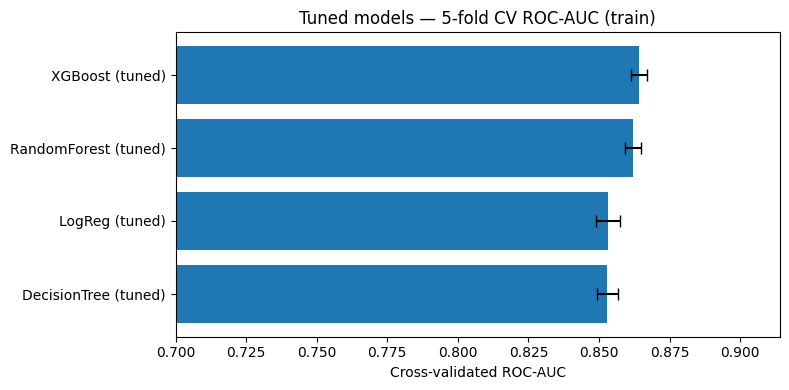

In [19]:
tuned = summary[summary["model"].str.contains("tuned")].sort_values("cv_roc_auc_mean")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(tuned["model"], tuned["cv_roc_auc_mean"],
        xerr=tuned["cv_roc_auc_std"], capsize=4)
ax.set_xlabel("Cross-validated ROC-AUC")
ax.set_xlim(0.7, max(tuned["cv_roc_auc_mean"]) + 0.05)
ax.set_title("Tuned models — 5-fold CV ROC-AUC (train)")
plt.tight_layout()
plt.show()

In [20]:
joblib.dump(best_lr,  MODELS_DIR / "logistic_regression.joblib")
joblib.dump(best_dt,  MODELS_DIR / "decision_tree.joblib")
joblib.dump(best_rf,  MODELS_DIR / "random_forest.joblib")
joblib.dump(best_xgb, MODELS_DIR / "xgboost.joblib")
summary.to_csv(MODELS_DIR / "cv_summary.csv", index=False)

print("Saved tuned models and CV summary to", MODELS_DIR.resolve())

Saved tuned models and CV summary to C:\Users\user1\PycharmProjects\credit-risk-assessment\notebooks\models


## 10. Summary and hand-off

We first settled the imbalance question left open by notebook 02, comparing no handling,
class weighting and per-fold SMOTENC under identical cross-validation, and adopted
cost-sensitive weighting. We then trained and tuned four classifiers under one
leakage-safe protocol: two interpretable baselines (logistic regression, decision tree)
and two ensembles (random forest, XGBoost), each motivated by its mathematics — the
convex log-loss and odds-ratio reading of logistic regression, impurity-based splitting
in trees, the variance-reduction argument behind forests, and the second-order
regularized objective of XGBoost.

The tuned models are persisted to disk. In `04_evaluation` we load them, evaluate on the
frozen test set with the full metric suite (ROC-AUC, PR-AUC, KS, Brier score), study
**probability calibration**, and use **SHAP** for model-agnostic interpretation, before
recommending a final model.

### References
- Hastie, Tibshirani, Friedman — *The Elements of Statistical Learning* (logistic regression, trees, bagging).
- Breiman (2001) — *Random Forests*.
- Chen & Guestrin (2016) — *XGBoost: A Scalable Tree Boosting System*.
- Chawla et al. (2002) — *SMOTE: Synthetic Minority Over-sampling Technique*.
- Kaggle — *Give Me Some Credit* competition dataset.
- scikit-learn, XGBoost and imbalanced-learn official documentation.